In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, lognorm, gamma
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path("../src").resolve()))

warnings.simplefilter(action="ignore", category=FutureWarning)

from dataloader import load_data_csv
from preprocessor import Preprocessor
from config import Config


In [21]:
config_path = Path("../config.toml").resolve()
config = Config.load(config_path)
df = load_data_csv(config)

preprocessor = Preprocessor(config)
df = preprocessor.run()
df

2025-03-29 11:06:39.795 | INFO     | dataloader:load_data_csv:36 - Data geladen met 9899 rijen.


2025-03-29 11:06:39.861 | INFO     | dataloader:load_data_csv:36 - Data geladen met 9899 rijen.
2025-03-29 11:06:39.890 | INFO     | preprocessor:clean_authors:27 - Authors opgeschoond.
2025-03-29 11:06:39.899 | INFO     | preprocessor:anonymize_authors:46 - 13 auteurs geanonimiseerd.
2025-03-29 11:06:39.910 | INFO     | preprocessor:add_message_length:51 - Kolom 'message_length' toegevoegd met lengte van elk bericht.
2025-03-29 11:06:39.928 | INFO     | preprocessor:add_author_info:57 - Auteur-info toegevoegd voor 13 auteurs.
2025-03-29 11:06:39.998 | INFO     | preprocessor:filter_automatic_messages:68 - 1534 automatische berichten verwijderd.
2025-03-29 11:06:40.027 | INFO     | preprocessor:filter_messages_after_september_2023:79 - 154 berichten vóór 1 september 2023 verwijderd.


,timestamp,author,message,message_length,age,gender,is_inlaw
196,2023-09-01 10:53:30,sprightly-rhinoceros,Wat we triestig weer zeg man man man\n,38,33.0,m,False
197,2023-09-01 10:56:11,snappy-ermine,Pff echt he\n,13,30.0,m,False
198,2023-09-01 10:56:39,decorated-shark,Duurt nog ff....pfffff 😢\n,26,55.0,f,False
199,2023-09-01 10:57:03,snappy-ermine,Na vandaag wel goed weer op komst lijkt 👌🏼\n,44,30.0,m,False
200,2023-09-01 10:58:44,decorated-shark,"Oh, gelukkig.\n",15,55.0,f,False
...,...,...,...,...,...,...,...
9893,2025-03-16 16:12:35,good-natured-ermine,Als ze aan zet echt niet normaal\n,34,25.0,f,False
9894,2025-03-16 17:16:14,crystalline-turkey,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",62,37.0,m,False
9895,2025-03-16 22:33:05,crystalline-turkey,"Wij zijn weer in Nederland, net de wieltjes w...",62,37.0,m,False
9896,2025-03-17 07:24:32,groovy-salmon,Welcome back! 💪🏻\n,18,35.0,m,False


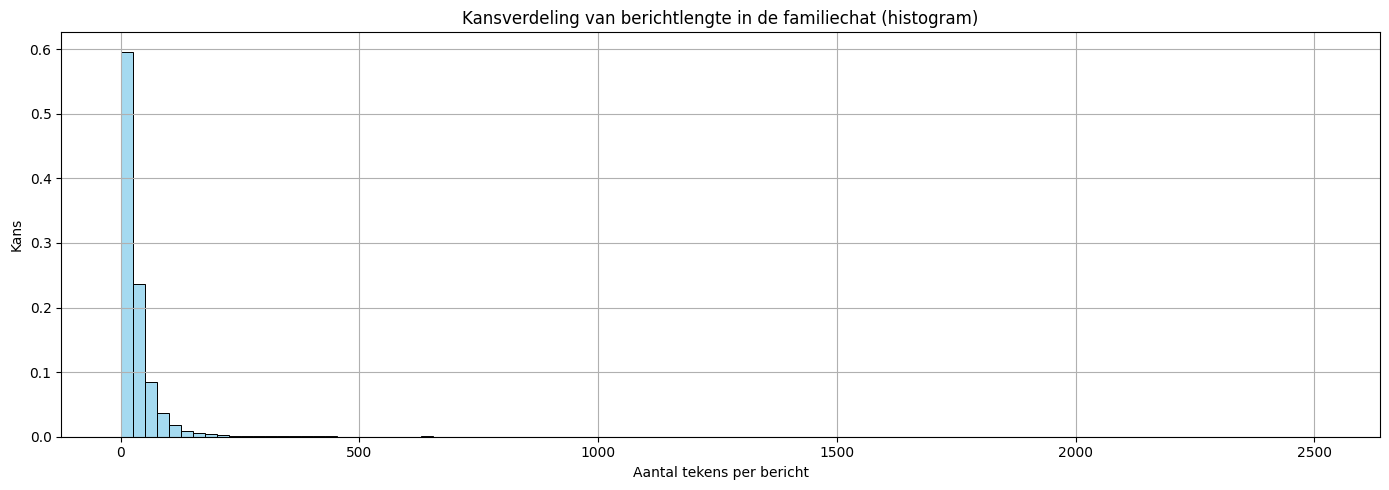

In [20]:
# Plot histogram
plt.figure(figsize=(14, 5))
sns.histplot(
    data=df,
    x="message_length",
    bins=100, 
    stat="probability",  # y-as = kans, niet frequentie
    color="skyblue",
    edgecolor="black"
)

plt.xlabel("Aantal tekens per bericht")
plt.ylabel("Kans")
plt.title("Kansverdeling van berichtlengte in de familiechat (histogram)")
plt.grid(True)
plt.tight_layout()
plt.show()

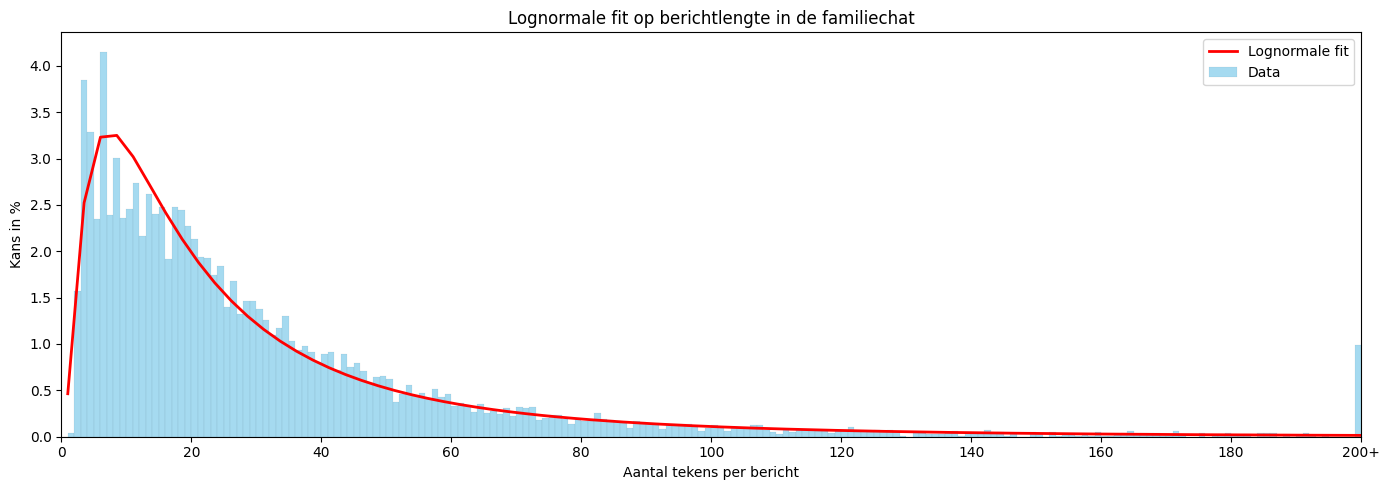

In [19]:
# Alleen positieve lengtes
message_lengths = df["message"].str.len()
positive_lengths = message_lengths[message_lengths > 0]

# Maak bins: 0–200 in stappen van 1 + alles daarboven in 1 bin
bins = list(range(0, 200, 1)) + [positive_lengths.max()]

# Lognormale fit
shape, loc, scale = lognorm.fit(positive_lengths, floc=0)
x = np.linspace(positive_lengths.min(), positive_lengths.max(), 1000)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

# Schaal naar percentage: pdf * 100 * binbreedte
bin_width = np.diff(bins)[0]  # bijvoorbeeld 1
pdf_scaled = pdf * 100 * bin_width

# Plot histogram met aangepaste bins
plt.figure(figsize=(14, 5))
sns.histplot(
    positive_lengths,
    bins=bins,
    stat="percent",
    color="skyblue",
    edgecolor="black",
    label="Data"
)

# Plot fit
plt.plot(x, pdf_scaled, "r", lw=2, label="Lognormale fit")
plt.xlim(0, 200)
xticks = list(range(0, 200, 20)) + [200]
xtick_labels = [str(x) for x in xticks[:-1]] + ['200+']
plt.xticks(xticks, xtick_labels)

# Extra labels
plt.xlabel("Aantal tekens per bericht")
plt.ylabel("Kans in %")
plt.title("Lognormale fit op berichtlengte in de familiechat")
plt.legend()
plt.tight_layout()
plt.show()



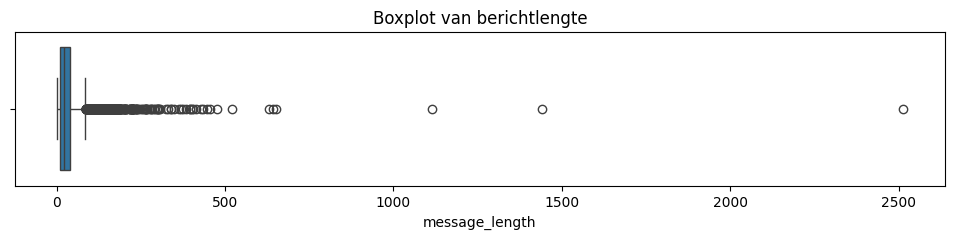

In [9]:
plt.figure(figsize=(12, 2))
sns.boxplot(x=df["message_length"])
plt.title("Boxplot van berichtlengte")
plt.show()


In [10]:
# Sorteer op lengte om de langste berichten te zien
longest_msgs = df.sort_values(by="message_length", ascending=False).head(10)
display(longest_msgs[["timestamp", "author", "message_length", "message"]])

,timestamp,author,message_length,message
9786,2025-03-06 18:30:34,pearlescent-ostrich,2512,\n\n“Dus stemden ze ervoor om een ​​muur te bo...
1800,2023-11-25 11:24:17,amusing-owl,1440,Mensen willen graag een bepaalde dag maar de ...
5196,2024-06-27 08:37:06,groovy-salmon,1113,"Best Lionel Messi,\n\nI heur you have nou bou..."
1846,2023-11-25 13:10:03,amusing-owl,650,De problemen met inloggen blijven helaas aan...
5761,2024-07-17 08:42:51,decorated-shark,643,"\nHalf 11 in t mortuarium, dan kan er nog iets..."
2836,2024-01-16 09:05:00,decorated-shark,630,"Goedemorgen samen, afgelopen maanden heb ik v..."
4757,2024-05-27 12:46:28,groovy-salmon,520,"Ja ik wil in de auto stappen, en zie ik ieman..."
1208,2023-10-26 19:08:03,crystalline-turkey,476,Gezien volgende week zat Sev z’n verjaardag i...
7100,2024-09-20 23:13:15,snappy-ermine,456,"Hoi hoi allen, volgende week zaterdag willen ..."
1363,2023-11-06 17:11:16,amusing-owl,446,Nee we hebben meer leden als we ieder 2 passe...


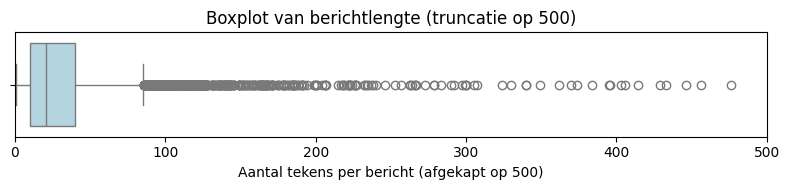

In [11]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df["message_length"], color="lightblue")
plt.xlim(0, 500)
plt.xlabel("Aantal tekens per bericht (afgekapt op 500)")
plt.title("Boxplot van berichtlengte (truncatie op 500)")
plt.tight_layout()
plt.show()


In [12]:
# Bekijk de verdeling
top_lengtes = df["message_length"].value_counts().sort_values(ascending=False)
print("Top meest voorkomende berichtlengtes:\n", top_lengtes.head())

# Filter op de uitschieter-lengte, bijvoorbeeld 25
uitschieter_waarde = top_lengtes.idxmax()  # pakt de meest voorkomende lengte automatisch
uitschieter_waarde
df[df["message_length"] == 20][["timestamp", "author", "message"]]

Top meest voorkomende berichtlengtes:
 message_length
6     341
3     316
4     270
8     247
11    225
Name: count, dtype: int64


,timestamp,author,message
269,2023-09-03 20:58:32,crystalline-turkey,Gvd lang vliegen 🫣\n
288,2023-09-05 13:51:48,merry-sparrow,Lekker genieten!😘😘\n
365,2023-09-09 09:24:44,variegated-nightingale,Gunstig voor ons 😜\n
484,2023-09-15 12:13:34,amusing-owl,Aanhanger is leeg.\n
488,2023-09-15 12:24:10,snappy-ermine,"Mooii, meevaller 😁\n"
...,...,...,...
9496,2025-02-21 19:41:13,decorated-shark,Dan zie je t niet\n
9597,2025-02-23 12:47:41,sprightly-rhinoceros,Heerlijk weertje 😊\n
9721,2025-03-02 16:05:01,good-natured-ermine,Woar stoan jullie?\n
9740,2025-03-03 18:14:30,good-natured-ermine,Volgend jaar Hahah\n
